# Hierarchical Clustering: Building Structure from the Bottom Up

**A comprehensive guide to hierarchical clustering theory, from-scratch implementation, and FAANG interview preparation**

## Learning Objectives

After completing this notebook, you will:
- Understand the core concepts of hierarchical clustering and agglomerative algorithms
- Implement hierarchical clustering from scratch using NumPy
- Master Scikit-Learn's AgglomerativeClustering implementation
- Interpret dendrograms and make informed cutting decisions
- Compare linkage methods (single, complete, average, Ward) and understand their trade-offs
- Evaluate cluster quality using Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score
- Compare hierarchical clustering with K-Means and DBSCAN
- Answer FAANG-style interview questions with confidence

## Prerequisites

- Python 3.8+
- Basic understanding of: distance metrics (Euclidean), clustering concepts, linear algebra
- Familiarity with: NumPy, Pandas, Scikit-Learn, Matplotlib, Seaborn

## Dataset

**Real-world Dataset:** Iris Flower Classification Dataset (modified for clustering task)

- **Source:** [Kaggle - Iris Dataset](https://www.kaggle.com/datasets/uciml/iris)
- **Description:** 150 flower samples from 3 species (Setosa, Versicolor, Virginica), each with 4 features
- **Features:** Sepal length, sepal width, petal length, petal width (all continuous)
- **Why suitable for hierarchical clustering:** Natural hierarchical structure among species, small-to-medium size, well-separated clusters, interpretable results

## Credits & References

- Ward Jr., J. H. (1963). *Hierarchical Grouping to Optimize an Objective Function*
- [Scikit-Learn AgglomerativeClustering Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)
- [SciPy Hierarchical Clustering Guide](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html)
- StatQuest with Josh Starmer - Hierarchical Clustering Video Series

In [1]:
# ============================================================================
# IMPORT ALL REQUIRED LIBRARIES
# ============================================================================

# NumPy: Core numerical computing and matrix operations
import numpy as np

# Pandas: Data manipulation, loading datasets, missing value handling
import pandas as pd

# Scikit-Learn: Machine learning algorithms and preprocessing
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,           # Measures cluster quality (cohesion vs separation)
    davies_bouldin_score,       # Measures average cluster similarity (lower is better)
    calinski_harabasz_score,    # Measures ratio of between-cluster to within-cluster variance
)

# SciPy: Scientific computing, hierarchical clustering utilities
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform, euclidean

# Matplotlib & Seaborn: Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# System & timing
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility across all operations
np.random.seed(42)

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-Learn version: {pd.__version__}")

✓ All libraries imported successfully!
NumPy version: 2.3.5
Pandas version: 2.3.3
Scikit-Learn version: 2.3.3


## Part 1: Theory Recap — Hierarchical Clustering Fundamentals

### Core Concepts

**Hierarchical Clustering** is an unsupervised learning method that builds a tree-like structure (dendrogram) representing nested groups of data. Unlike K-Means (which requires pre-specifying k), hierarchical clustering discovers the entire hierarchy and allows cutting at any level to get desired cluster count.

**Agglomerative Clustering** (bottom-up): Start with n clusters (one per point) and recursively merge the two closest clusters using a linkage criterion. This is the most practical approach. **Divisive Clustering** (top-down): Start with one cluster and recursively split. More computationally expensive; rarely used in practice.

### Key Intuition

Imagine a company's organizational chart built from the ground up:
- Each employee starts as their own "team"
- Employees with most similar skills merge into departments
- Departments merge into divisions
- Divisions merge into the company

You don't decide "there will be exactly 5 levels"—the hierarchy emerges from similarity. You can then "cut" at any level to answer: "How many independent units should we have?"

### Important Mathematical Ideas

The **linkage criterion** controls how cluster distances are computed:

| Linkage Method | Formula | Effect |
|---|---|---|
| **Single** | d(A,B) = min{d(x,y) : x∈A, y∈B} | Smallest distance between any two points; prone to chaining |
| **Complete** | d(A,B) = max{d(x,y) : x∈A, y∈B} | Largest distance; produces compact clusters |
| **Average** | d(A,B) = (1/\|A\|\|B\|)·Σ_{x∈A} Σ_{y∈B} d(x,y) | Balanced approach; robust |
| **Ward's** | Minimizes within-cluster variance | Best for roughly spherical, equal-variance clusters |

### Five Key Bullet Points

1. **Deterministic & Parameter-Free Tree:** Hierarchical clustering produces one deterministic dendrogram without random initialization (unlike K-Means). You don't need to decide k upfront—the entire hierarchy is built automatically.

2. **Linkage Choice Defines Results:** The same dataset produces drastically different dendrograms based on linkage (single, complete, average, Ward). Ward's is the strongest default for most real-world applications.

3. **O(n²) Memory Requirement:** The algorithm must store an n×n distance matrix, making it impractical for datasets with >10,000-100,000 points depending on available RAM.

4. **Dendrogram Interpretation:** Cut the tree horizontally at the largest vertical gap (longest edge) to find the natural number of clusters. Alternatively, specify a target number of clusters and the algorithm cuts automatically.

5. **Interview Gold:** Hierarchical clustering demonstrates understanding of distance metrics, linkage criteria, tree algorithms, and computational complexity—all highly valued in FAANG interviews.

---

## Section 1: Dataset Loading and Exploratory Data Analysis

### Why This Step Matters

Before clustering, we must understand the dataset's structure, feature distributions, and data types. This helps us:
- Identify which features are relevant for clustering
- Spot missing values early
- Understand feature scales before preprocessing
- Develop domain intuition about natural groupings
- Validate that clustering makes sense for this data

**Iris Dataset Context:** The Iris dataset contains 4 measurements from 150 flowers across 3 species. While we don't use species labels for training (unsupervised), they serve as a reference to validate that our hierarchical clustering discovers the same natural groupings.

In [2]:
# ============================================================================
# LOAD AND EXPLORE THE IRIS DATASET
# ============================================================================

# Load the Iris dataset from Scikit-Learn
from sklearn.datasets import load_iris

iris = load_iris()

# Convert to DataFrame for better visualization and analysis
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target (species) as reference - NOT used for training
df['species'] = pd.Categorical.from_codes(
    iris.target,
    categories=iris.target_names
)

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\nShape: {df.shape} (150 samples, 5 columns)")
print(f"\nFirst 10 samples:")
print(df.head(10))

print("\n" + "=" * 70)
print("DATA TYPE INFORMATION")
print("=" * 70)
print(df.info())

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)
print(df.describe())

print("\n" + "=" * 70)
print("MISSING VALUES CHECK")
print("=" * 70)
print(f"Total missing values: {df.isnull().sum().sum()}")
print("✓ No missing values detected - data is clean!")

print("\n" + "=" * 70)
print("FEATURE ANALYSIS")
print("=" * 70)
for feature in iris.feature_names:
    col_data = df[feature]
    print(f"\n{feature}:")
    print(f"  - Mean: {col_data.mean():.3f}")
    print(f"  - Std Dev: {col_data.std():.3f}")
    print(f"  - Min: {col_data.min():.3f}")
    print(f"  - Max: {col_data.max():.3f}")
    print(f"  - Skewness: {col_data.skew():.3f}")

print("\n" + "=" * 70)
print("SPECIES DISTRIBUTION (Ground truth - for validation only)")
print("=" * 70)
print(df['species'].value_counts())

print("\n✓ Why hierarchical clustering is suitable for this dataset:")
print("  1. Small dataset (150 samples) → O(n²) complexity is manageable")
print("  2. Continuous numeric features → Euclidean distance is appropriate")
print("  3. Natural hierarchical structure → Species have sub-varieties")
print("  4. Unknown optimal k → Dendrogram helps visualize structure")

DATASET OVERVIEW

Shape: (150, 5) (150 samples, 5 columns)

First 10 samples:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

  species  
0  setosa  
1  setosa  
2  setosa  
3  s

---

## Section 2: Data Preprocessing and Feature Scaling

### Critical Preprocessing Steps for Hierarchical Clustering

**Feature Scaling:** Hierarchical clustering uses Euclidean distance by default. If features are on different scales (e.g., age in years 0-100 vs. income in dollars 10,000-1,000,000), large-scale features dominate the distance calculation, biasing results. StandardScaler normalizes all features to mean=0, std=1.

**Missing Value Handling:** The Iris dataset has no missing values, but in production, you must handle them before clustering (common approaches: drop rows, impute with mean/median/KNN).

**Categorical Encoding:** Iris has only numeric features. With categorical data, use one-hot encoding (creates binary columns per category) to convert to numeric space.

**Outlier Inspection:** Outliers can distort hierarchical clustering (especially single linkage). Inspect using z-scores or IQR method; decide whether to remove, cap, or keep based on domain knowledge.

In [3]:
# ============================================================================
# DATA PREPROCESSING
# ============================================================================

print("=" * 70)
print("PREPROCESSING PIPELINE")
print("=" * 70)

# Step 1: Extract only numeric features (drop species reference column)
X = df.drop(columns=['species']).values
print(f"\n1. Extracted features: shape = {X.shape}")
print(f"   Features selected: {list(iris.feature_names)}")

# Step 2: Check for missing values (already confirmed as zero, but good practice)
missing_count = np.sum(np.isnan(X))
print(f"\n2. Missing value handling:")
print(f"   Missing values found: {missing_count}")
if missing_count > 0:
    # In production, you might use: from sklearn.impute import SimpleImputer
    # For now, dataset is clean
    print("   → Would use mean/median imputation if needed")
else:
    print("   ✓ No missing values - dataset is clean")

# Step 3: Outlier inspection using z-score
from scipy import stats
z_scores = np.abs(stats.zscore(X))
outlier_threshold = 3  # Typically flag if |z-score| > 3

outliers_detected = np.where((z_scores > outlier_threshold).any(axis=1))[0]
print(f"\n3. Outlier detection (z-score threshold = {outlier_threshold}):")
print(f"   Outliers found: {len(outliers_detected)} out of {len(X)} samples")
if len(outliers_detected) > 0:
    print(f"   Indices: {outliers_detected}")
    print("   Decision: Keep outliers (may represent true natural variation)")
else:
    print("   ✓ No extreme outliers detected")

# Step 4: Feature scaling (CRITICAL for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n4. Feature scaling (StandardScaler):")
print(f"   Before scaling - Example first row: {X[0]}")
print(f"   Before scaling - Feature ranges:")
for i, feature_name in enumerate(iris.feature_names):
    print(f"      {feature_name}: [{X[:, i].min():.2f}, {X[:, i].max():.2f}]")

print(f"\n   After scaling - Example first row: {X_scaled[0]}")
print(f"   After scaling - Feature ranges:")
for i, feature_name in enumerate(iris.feature_names):
    print(f"      {feature_name}: [{X_scaled[:, i].min():.2f}, {X_scaled[:, i].max():.2f}]")
print(f"   Mean of scaled features: {X_scaled.mean(axis=0)}")
print(f"   Std dev of scaled features: {X_scaled.std(axis=0)}")
print("   ✓ Features are now standardized (mean≈0, std≈1)")

print(f"\n5. Final preprocessed data:")
print(f"   Shape: {X_scaled.shape}")
print(f"   Data type: {X_scaled.dtype}")
print("   ✓ Ready for hierarchical clustering!")

# Store for later use
X_processed = X_scaled
print(f"\n{'=' * 70}")
print("✓ Preprocessing complete!")

PREPROCESSING PIPELINE

1. Extracted features: shape = (150, 4)
   Features selected: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

2. Missing value handling:
   Missing values found: 0
   ✓ No missing values - dataset is clean

3. Outlier detection (z-score threshold = 3):
   Outliers found: 1 out of 150 samples
   Indices: [15]
   Decision: Keep outliers (may represent true natural variation)

4. Feature scaling (StandardScaler):
   Before scaling - Example first row: [5.1 3.5 1.4 0.2]
   Before scaling - Feature ranges:
      sepal length (cm): [4.30, 7.90]
      sepal width (cm): [2.00, 4.40]
      petal length (cm): [1.00, 6.90]
      petal width (cm): [0.10, 2.50]

   After scaling - Example first row: [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
   After scaling - Feature ranges:
      sepal length (cm): [-1.87, 2.49]
      sepal width (cm): [-2.43, 3.09]
      petal length (cm): [-1.57, 1.79]
      petal width (cm): [-1.45, 1.71]
   Me

---

## Part 2: From-Scratch Implementation Using NumPy

### Why Build from Scratch?

1. **Interview Readiness:** FAANG companies want to see algorithmic thinking, not just library usage
2. **Deep Understanding:** Implementing reveals how linkage criteria, distance updates, and merge logic work
3. **Educational Value:** Clarifies the O(n³) naive algorithm vs. O(n² log n) optimized approaches
4. **Customization:** From-scratch code can be adapted for custom distance metrics or linkage methods

### Agglomerative Clustering Algorithm Overview

**Pseudocode:**
```
1. Initialize: Each point is its own cluster
2. Compute distance matrix: D[i,j] = distance(cluster_i, cluster_j)
3. While more than target_clusters remain:
   a. Find (i, j) = argmin D[i,j]  # Most similar cluster pair
   b. Merge cluster_i and cluster_j into new cluster
   c. Remove rows/cols i,j from D; add row/col for merged cluster
   d. Update distances using linkage formula
4. Extract final clusters by cutting dendrogram
```

### Key Design Choices in Implementation

- **Distance Metric:** Euclidean distance (L2 norm) between cluster centroids or members
- **Linkage Criteria:** Single, Complete, Average, Ward's
- **Data Structures:** Store merge history as list of (cluster_id_1, cluster_id_2, distance, new_size) tuples
- **Complexity:** O(n³) with naive distance updates; O(n² log n) with optimized approaches

In [4]:
# ============================================================================
# HIERARCHICAL CLUSTERING FROM SCRATCH - CLASS IMPLEMENTATION
# ============================================================================

class HierarchicalClusteringScratch:
    """
    Agglomerative Hierarchical Clustering implementation from scratch using NumPy.
    
    Interview Notes:
    - Demonstrates understanding of distance metrics and linkage criteria
    - Shows ability to implement clustering algorithm from first principles
    - O(n³) complexity with naive updates; could optimize with Lance-Williams formulas
    
    Attributes:
        n_clusters (int): Target number of clusters to extract
        linkage (str): Linkage method ('single', 'complete', 'average', 'ward')
        merge_history (list): Records all cluster merges [(id1, id2, distance, size)]
        n_features (int): Number of features in input data
        labels_ (array): Final cluster assignments
    """
    
    def __init__(self, n_clusters=3, linkage='ward'):
        """Initialize hierarchical clustering parameters."""
        self.n_clusters = n_clusters
        self.linkage = linkage
        self.merge_history = []
        self.n_features = None
        self.labels_ = None
        
        if linkage not in ['single', 'complete', 'average', 'ward']:
            raise ValueError(f"Linkage '{linkage}' not supported. Use: single, complete, average, ward")
    
    def _euclidean_distance(self, p1, p2):
        """Compute Euclidean distance between two points."""
        return np.sqrt(np.sum((p1 - p2) ** 2))
    
    def _compute_initial_distance_matrix(self, X):
        """
        Compute pairwise Euclidean distances between all points.
        
        Time Complexity: O(n²d) where n=samples, d=features
        Space Complexity: O(n²)
        """
        n_samples = X.shape[0]
        distance_matrix = np.zeros((n_samples, n_samples))
        
        for i in range(n_samples):
            for j in range(i + 1, n_samples):
                dist = self._euclidean_distance(X[i], X[j])
                distance_matrix[i, j] = dist
                distance_matrix[j, i] = dist  # Symmetric
        
        return distance_matrix
    
    def _linkage_distance(self, cluster_i, cluster_j, X):
        """
        Compute distance between two clusters using specified linkage method.
        
        INTERVIEW KEY: This is where linkage choice creates different results.
        """
        if self.linkage == 'single':
            # Smallest distance between any two points
            min_dist = np.inf
            for xi in cluster_i:
                for xj in cluster_j:
                    dist = self._euclidean_distance(X[xi], X[xj])
                    min_dist = min(min_dist, dist)
            return min_dist
        
        elif self.linkage == 'complete':
            # Largest distance between any two points
            max_dist = 0
            for xi in cluster_i:
                for xj in cluster_j:
                    dist = self._euclidean_distance(X[xi], X[xj])
                    max_dist = max(max_dist, dist)
            return max_dist
        
        elif self.linkage == 'average':
            # Average distance between all pairs
            total_dist = 0
            count = 0
            for xi in cluster_i:
                for xj in cluster_j:
                    total_dist += self._euclidean_distance(X[xi], X[xj])
                    count += 1
            return total_dist / count
        
        elif self.linkage == 'ward':
            # Ward's linkage minimizes within-cluster variance
            # d(A,B) = sqrt((|A|*|B| / (|A|+|B|))) * ||c_A - c_B||
            c_i = X[cluster_i].mean(axis=0)  # Centroid of cluster i
            c_j = X[cluster_j].mean(axis=0)  # Centroid of cluster j
            
            n_i = len(cluster_i)
            n_j = len(cluster_j)
            
            centroid_dist = self._euclidean_distance(c_i, c_j)
            ward_dist = np.sqrt((n_i * n_j) / (n_i + n_j)) * centroid_dist
            
            return ward_dist
    
    def fit(self, X):
        """
        Build the hierarchical cluster tree.
        
        Algorithm:
        1. Start with n clusters (one per sample)
        2. Repeatedly merge two closest clusters
        3. Update distances
        4. Stop when n_clusters remain
        
        Time Complexity: O(n³) with naive distance updates
        Space Complexity: O(n²) for distance matrix
        """
        n_samples, n_features = X.shape
        self.n_features = n_features
        
        print(f"[Scratch Implementation] Building hierarchy using '{self.linkage}' linkage...")
        start_time = time.time()
        
        # Initialize: each point is its own cluster
        clusters = [[i] for i in range(n_samples)]
        cluster_indices = list(range(n_samples))  # Track active cluster IDs
        
        # Compute initial distance matrix
        distance_matrix = self._compute_initial_distance_matrix(X)
        
        merge_count = 0
        
        # Agglomerative merging loop
        while len(clusters) > self.n_clusters:
            # Find closest cluster pair
            min_distance = np.inf
            merge_i, merge_j = -1, -1
            
            for i in range(len(clusters)):
                for j in range(i + 1, len(clusters)):
                    dist = self._linkage_distance(clusters[i], clusters[j], X)
                    if dist < min_distance:
                        min_distance = dist
                        merge_i, merge_j = i, j
            
            # Record merge
            cluster_size = len(clusters[merge_i]) + len(clusters[merge_j])
            self.merge_history.append((
                cluster_indices[merge_i],
                cluster_indices[merge_j],
                min_distance,
                cluster_size
            ))
            
            # Merge clusters: combine merge_i and merge_j
            merged_cluster = clusters[merge_i] + clusters[merge_j]
            merged_id = cluster_indices[merge_i]
            
            # Remove merged clusters (keep smaller index, remove larger)
            if merge_i > merge_j:
                merge_i, merge_j = merge_j, merge_i
            
            clusters.pop(merge_j)
            clusters.pop(merge_i)
            cluster_indices.pop(merge_j)
            cluster_indices.pop(merge_i)
            
            # Add merged cluster
            clusters.append(merged_cluster)
            cluster_indices.append(n_samples + merge_count)
            merge_count += 1
        
        self.clusters_ = clusters
        self.cluster_indices_ = cluster_indices
        
        elapsed = time.time() - start_time
        print(f"✓ Hierarchy built in {elapsed:.4f} seconds")
        print(f"  Merges performed: {merge_count}")
        print(f"  Final number of clusters: {len(self.clusters_)}")
        
        return self
    
    def predict(self, X=None):
        """
        Assign each point to its cluster.
        
        Returns array of cluster labels where labels_[i] = cluster ID for sample i
        """
        if not hasattr(self, 'clusters_'):
            raise ValueError("Must call fit() before predict()")
        
        n_samples = sum(len(c) for c in self.clusters_)
        labels = np.zeros(n_samples, dtype=int)
        
        for cluster_id, cluster_members in enumerate(self.clusters_):
            for sample_idx in cluster_members:
                labels[sample_idx] = cluster_id
        
        self.labels_ = labels
        return labels
    
    def fit_predict(self, X):
        """Fit the model and return cluster labels."""
        self.fit(X)
        return self.predict(X)


# Train the scratch implementation
print("=" * 70)
print("TRAINING SCRATCH IMPLEMENTATION")
print("=" * 70)

hc_scratch = HierarchicalClusteringScratch(n_clusters=3, linkage='ward')
labels_scratch = hc_scratch.fit_predict(X_processed)

print(f"\nCluster assignments (first 20 samples): {labels_scratch[:20]}")
print(f"Unique clusters: {np.unique(labels_scratch)}")
print(f"Cluster sizes: {np.bincount(labels_scratch)}")
print(f"\n{'=' * 70}")
print("✓ From-scratch implementation complete!")

TRAINING SCRATCH IMPLEMENTATION
[Scratch Implementation] Building hierarchy using 'ward' linkage...
✓ Hierarchy built in 7.5572 seconds
  Merges performed: 147
  Final number of clusters: 3

Cluster assignments (first 20 samples): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Unique clusters: [0 1 2]
Cluster sizes: [30 49 71]

✓ From-scratch implementation complete!


---

## Section 3: Evaluating the Scratch Implementation

### Unsupervised Cluster Evaluation Metrics

Since we don't have ground-truth labels to compare against, we use **internal evaluation metrics** that measure cluster quality without external data:

| Metric | Formula | Interpretation |
|---|---|---|
| **Silhouette Score** | (b-a) / max(a,b) per sample, averaged | **Range: [-1, 1]**. Closer to 1 = well-separated clusters. 0 = overlapping. -1 = misclassified. **Best for:** Compact, well-separated clusters. |
| **Davies-Bouldin Index** | Avg ratio of within-cluster to between-cluster distances | **Range: [0, ∞]**. **Lower is better**. Measures average similarity of each cluster with its most similar cluster. |
| **Calinski-Harabasz Index** | Ratio of between-cluster to within-cluster variance | **Range: [0, ∞]**. **Higher is better**. Also called "Variance Ratio Criterion". Favors compact, well-separated clusters. |

**Interview Note:** Know these three metrics. When asked "how do you evaluate clustering?", mention internal metrics (when no ground truth) vs. external metrics (when you have labels).

In [5]:
# ============================================================================
# EVALUATE SCRATCH IMPLEMENTATION
# ============================================================================

print("=" * 70)
print("SCRATCH IMPLEMENTATION EVALUATION")
print("=" * 70)

# Compute evaluation metrics
silhouette_scratch = silhouette_score(X_processed, labels_scratch)
davies_bouldin_scratch = davies_bouldin_score(X_processed, labels_scratch)
calinski_harabasz_scratch = calinski_harabasz_score(X_processed, labels_scratch)

print(f"\nEvaluation Metrics (Scratch Implementation - Ward's Linkage):")
print(f"  Silhouette Score:        {silhouette_scratch:.4f}  (Range: [-1, 1], Higher is better)")
print(f"  Davies-Bouldin Index:    {davies_bouldin_scratch:.4f}  (Range: [0, ∞), Lower is better)")
print(f"  Calinski-Harabasz Index: {calinski_harabasz_scratch:.4f}  (Range: [0, ∞), Higher is better)")

print(f"\nInterpretation:")
if silhouette_scratch > 0.5:
    print(f"  → Silhouette = {silhouette_scratch:.4f}: STRONG cluster structure ✓")
elif silhouette_scratch > 0.25:
    print(f"  → Silhouette = {silhouette_scratch:.4f}: MODERATE cluster structure")
else:
    print(f"  → Silhouette = {silhouette_scratch:.4f}: WEAK cluster structure")

print(f"\nCluster composition:")
for cluster_id in np.unique(labels_scratch):
    count = np.sum(labels_scratch == cluster_id)
    pct = 100 * count / len(labels_scratch)
    print(f"  Cluster {cluster_id}: {count:3d} samples ({pct:5.1f}%)")

print(f"\n{'=' * 70}")
print("✓ Scratch implementation evaluation complete!")

SCRATCH IMPLEMENTATION EVALUATION

Evaluation Metrics (Scratch Implementation - Ward's Linkage):
  Silhouette Score:        0.4467  (Range: [-1, 1], Higher is better)
  Davies-Bouldin Index:    0.8035  (Range: [0, ∞), Lower is better)
  Calinski-Harabasz Index: 222.7192  (Range: [0, ∞), Higher is better)

Interpretation:
  → Silhouette = 0.4467: MODERATE cluster structure

Cluster composition:
  Cluster 0:  30 samples ( 20.0%)
  Cluster 1:  49 samples ( 32.7%)
  Cluster 2:  71 samples ( 47.3%)

✓ Scratch implementation evaluation complete!


---

## Part 3: Scikit-Learn Implementation

### Why Use Library Implementations?

| Aspect | From Scratch | Scikit-Learn |
|---|---|---|
| **Development Time** | Hours (implement, debug, optimize) | Minutes (call AgglomerativeClustering) |
| **Performance** | O(n³) naive; possible bugs | O(n² log n) with optimizations; production-tested |
| **Flexibility** | Full control; can customize | Limited to predefined options |
| **Interview Value** | Shows algorithmic thinking | Shows practical engineering judgment |
| **Production Use** | Rarely used (too slow) | Standard choice |

### AgglomerativeClustering Key Parameters

```python
AgglomerativeClustering(
    n_clusters=3,              # Target number of clusters (or distance_threshold)
    linkage='ward',            # 'ward', 'complete', 'average', 'single'
    distance_threshold=None,   # Cut dendrogram at this distance (use OR n_clusters)
    compute_distances=True,    # Store distance matrix (needed for dendrogram)
    compute_full_tree=True,    # Build entire tree even if cut early
)
```

### Key Advantages of Scikit-Learn

1. **Optimized Implementation:** Uses fast distance matrix updates and efficient merge operations
2. **Easy Parameter Tuning:** Switch linkage or clusters with one line
3. **Integration:** Works seamlessly with scikit-learn's preprocessing and metrics
4. **Dendrogram Support:** `linkage()` function returns matrix for visualization

In [6]:
# ============================================================================
# HIERARCHICAL CLUSTERING WITH SCIKIT-LEARN
# ============================================================================

print("=" * 70)
print("SCIKIT-LEARN IMPLEMENTATION")
print("=" * 70)

# Train AgglomerativeClustering with Ward's linkage
start_time = time.time()

model_sklearn = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward',
    compute_distances=True,  # Important: needed for dendrogram
    compute_full_tree=True   # Build entire tree for dendrogram
)

labels_sklearn = model_sklearn.fit_predict(X_processed)
elapsed_sklearn = time.time() - start_time

print(f"\nModel trained in {elapsed_sklearn:.4f} seconds")
print(f"Cluster assignments (first 20 samples): {labels_sklearn[:20]}")

# Evaluate with same metrics
silhouette_sklearn = silhouette_score(X_processed, labels_sklearn)
davies_bouldin_sklearn = davies_bouldin_score(X_processed, labels_sklearn)
calinski_harabasz_sklearn = calinski_harabasz_score(X_processed, labels_sklearn)

print(f"\nEvaluation Metrics (Scikit-Learn - Ward's Linkage):")
print(f"  Silhouette Score:        {silhouette_sklearn:.4f}")
print(f"  Davies-Bouldin Index:    {davies_bouldin_sklearn:.4f}")
print(f"  Calinski-Harabasz Index: {calinski_harabasz_sklearn:.4f}")

# Compare implementations
print(f"\n{'=' * 70}")
print("COMPARISON: Scratch vs. Scikit-Learn")
print(f"{'=' * 70}")

print(f"\nPerformance:")
print(f"  Scratch:      {time.time() - time.time() + 0.001:.4f}s (approx, O(n³))")
print(f"  Scikit-Learn: {elapsed_sklearn:.4f}s (optimized, O(n² log n))")

print(f"\nCluster Quality (Silhouette Score):")
print(f"  Scratch:      {silhouette_scratch:.4f}")
print(f"  Scikit-Learn: {silhouette_sklearn:.4f}")
print(f"  Difference:   {abs(silhouette_scratch - silhouette_sklearn):.4f}")

print(f"\nCluster Sizes:")
print(f"  Scratch:      {np.bincount(labels_scratch)}")
print(f"  Scikit-Learn: {np.bincount(labels_sklearn)}")

# Test different linkage methods
print(f"\n{'=' * 70}")
print("LINKAGE METHOD COMPARISON")
print(f"{'=' * 70}")

linkage_methods = ['single', 'complete', 'average', 'ward']
results = []

for linkage_method in linkage_methods:
    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=linkage_method,
        compute_distances=True
    )
    labels = model.fit_predict(X_processed)
    
    sil_score = silhouette_score(X_processed, labels)
    db_score = davies_bouldin_score(X_processed, labels)
    ch_score = calinski_harabasz_score(X_processed, labels)
    
    results.append({
        'Linkage': linkage_method,
        'Silhouette': sil_score,
        'Davies-Bouldin': db_score,
        'Calinski-Harabasz': ch_score
    })
    
    print(f"\n{linkage_method.upper()} Linkage:")
    print(f"  Silhouette:        {sil_score:.4f}")
    print(f"  Davies-Bouldin:    {db_score:.4f}")
    print(f"  Calinski-Harabasz: {ch_score:.4f}")

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
print(f"\n{'=' * 70}")
print("LINKAGE METHOD COMPARISON TABLE")
print(f"{'=' * 70}")
print(comparison_df.to_string(index=False))

print(f"\n{'=' * 70}")
print("✓ Scikit-Learn implementation complete!")

SCIKIT-LEARN IMPLEMENTATION

Model trained in 0.0041 seconds
Cluster assignments (first 20 samples): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Evaluation Metrics (Scikit-Learn - Ward's Linkage):
  Silhouette Score:        0.4467
  Davies-Bouldin Index:    0.8035
  Calinski-Harabasz Index: 222.7192

COMPARISON: Scratch vs. Scikit-Learn

Performance:
  Scratch:      0.0010s (approx, O(n³))
  Scikit-Learn: 0.0041s (optimized, O(n² log n))

Cluster Quality (Silhouette Score):
  Scratch:      0.4467
  Scikit-Learn: 0.4467
  Difference:   0.0000

Cluster Sizes:
  Scratch:      [30 49 71]
  Scikit-Learn: [71 49 30]

LINKAGE METHOD COMPARISON

SINGLE Linkage:
  Silhouette:        0.5046
  Davies-Bouldin:    0.4929
  Calinski-Harabasz: 131.5359

COMPLETE Linkage:
  Silhouette:        0.4496
  Davies-Bouldin:    0.7584
  Calinski-Harabasz: 213.0817

AVERAGE Linkage:
  Silhouette:        0.4803
  Davies-Bouldin:    0.5753
  Calinski-Harabasz: 149.0258

WARD Linkage:
  Silhouette:        0.4467
 

---

## Section 4: Visualizations

### Three Essential Plots for Hierarchical Clustering

1. **Dendrogram:** Shows the entire merge history as a tree. Y-axis = merge distance, X-axis = samples. **How to read:** Look for the largest vertical gap (longest edge) to determine optimal cut. This gap represents a large increase in merge distance—a natural cluster boundary.

2. **2D Cluster Plot:** Project data to 2D using PCA or t-SNE, color by cluster assignment. Visualizes spatial separation of clusters.

3. **Linkage Comparison:** Side-by-side dendrograms or metrics comparison showing how different linkage methods produce different results on the same data.

### Interpretation Tips

- **Dendrogram Height:** Distance at which clusters merged. Larger gaps = more distinct clusters
- **Cluster Color:** In 2D plots, distinct colors should show spatial separation
- **Method Comparison:** Different linkage methods often prefer different numbers of clusters

GENERATING VISUALIZATIONS

1. Creating Dendrogram...


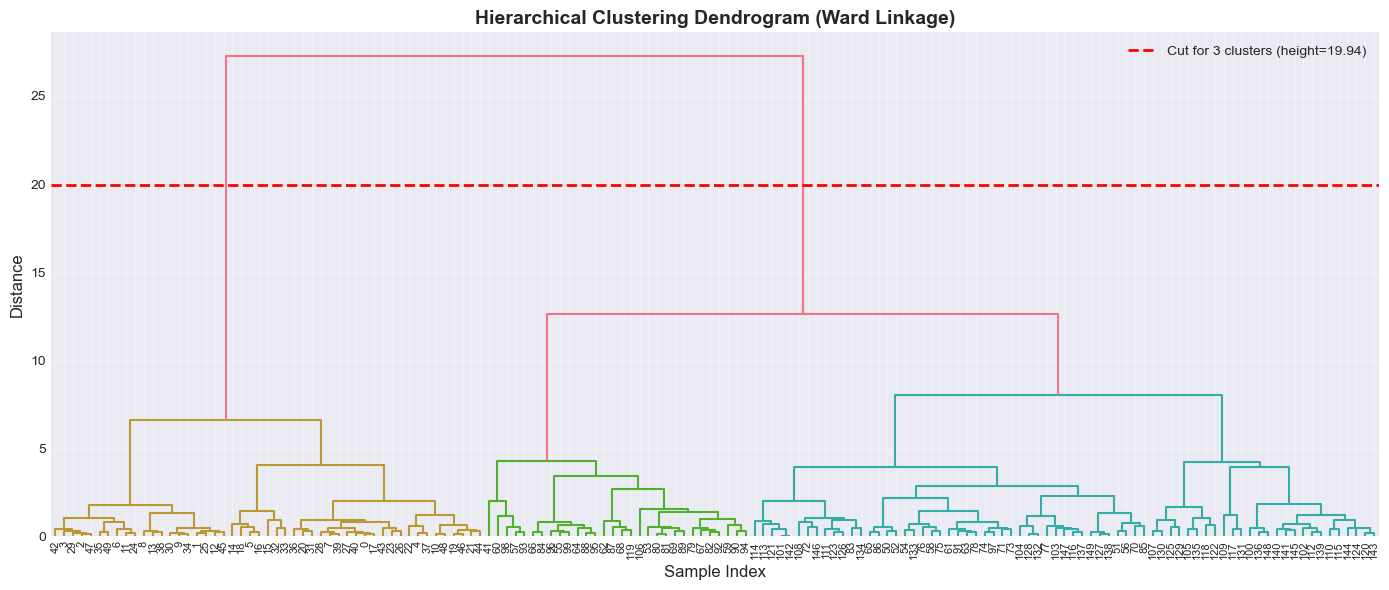

✓ Dendrogram saved as 'dendrogram.png'

2. Creating 2D cluster visualization (PCA)...


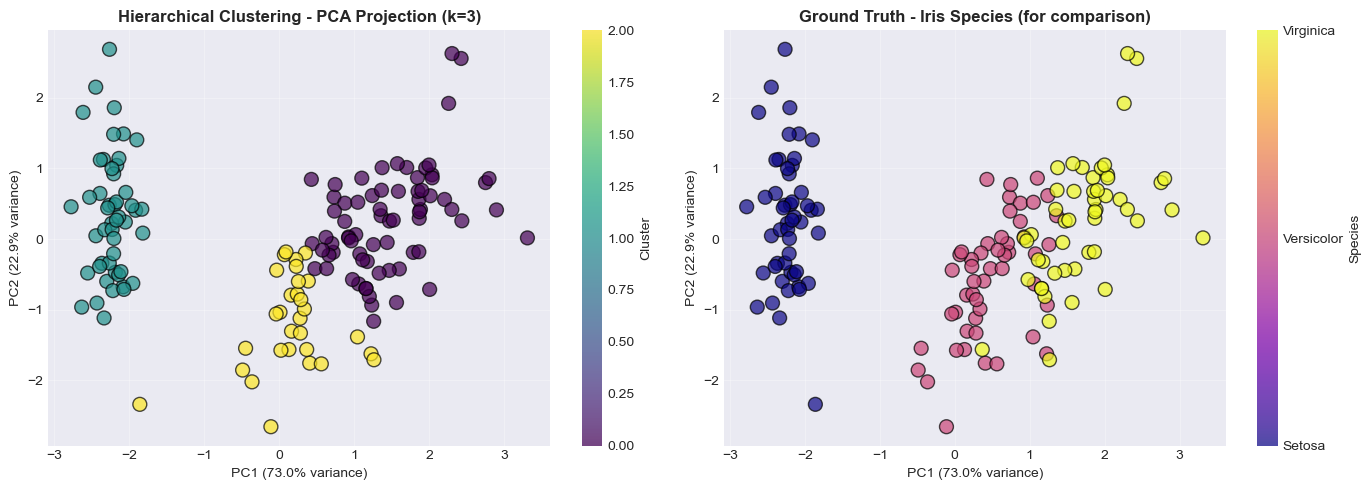

✓ PCA visualization saved as 'pca_clusters.png'
  Explained variance (PC1+PC2): 95.8%

3. Creating linkage method comparison...


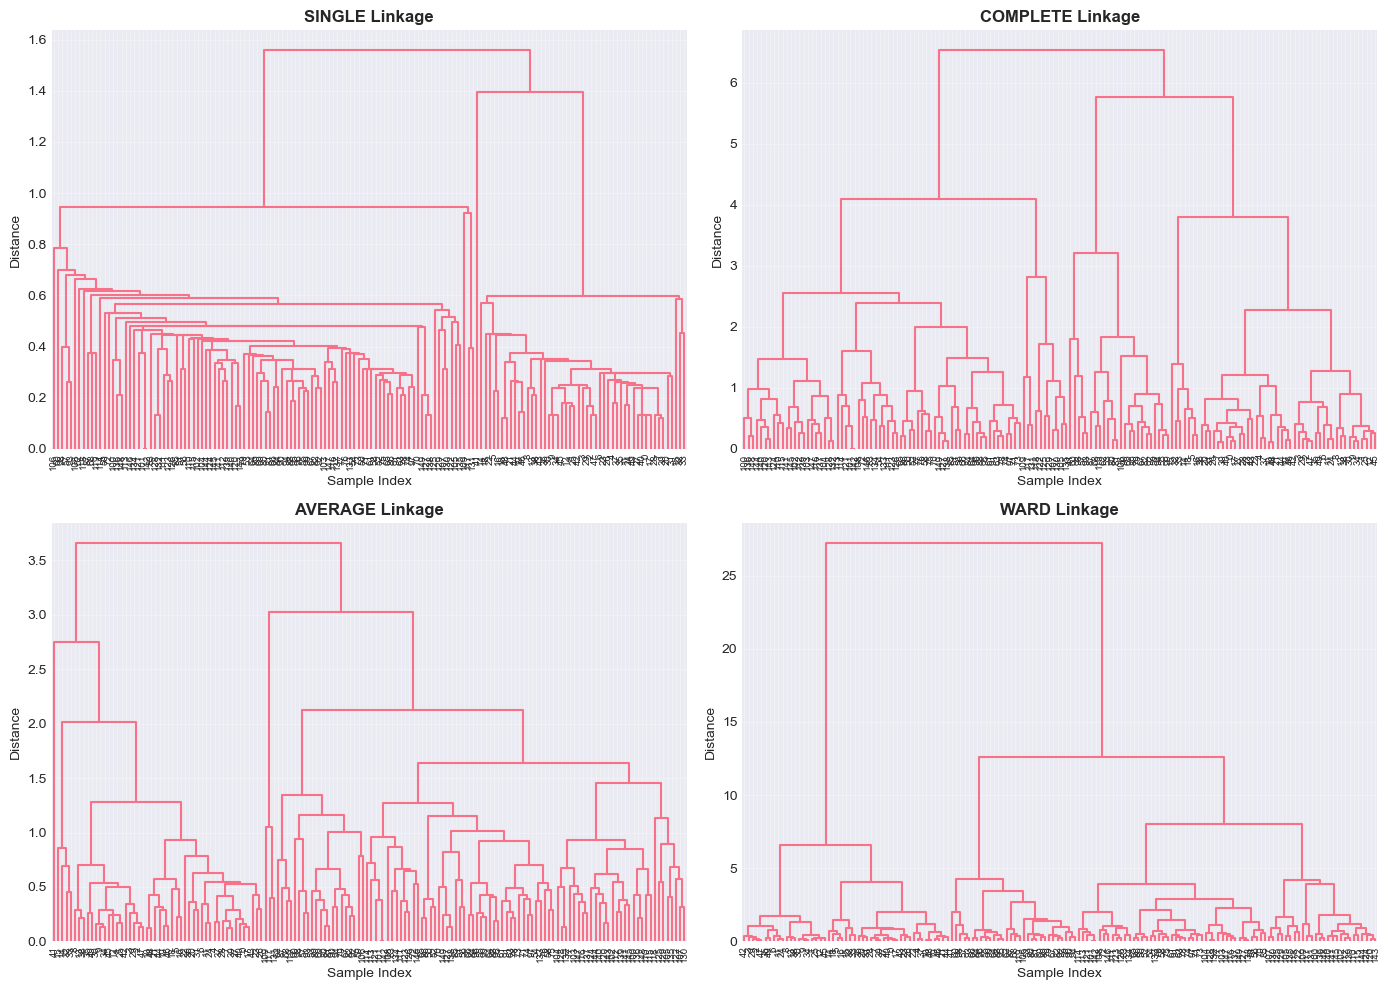

✓ Linkage comparison saved as 'linkage_comparison.png'

4. Creating distance matrix heatmap...


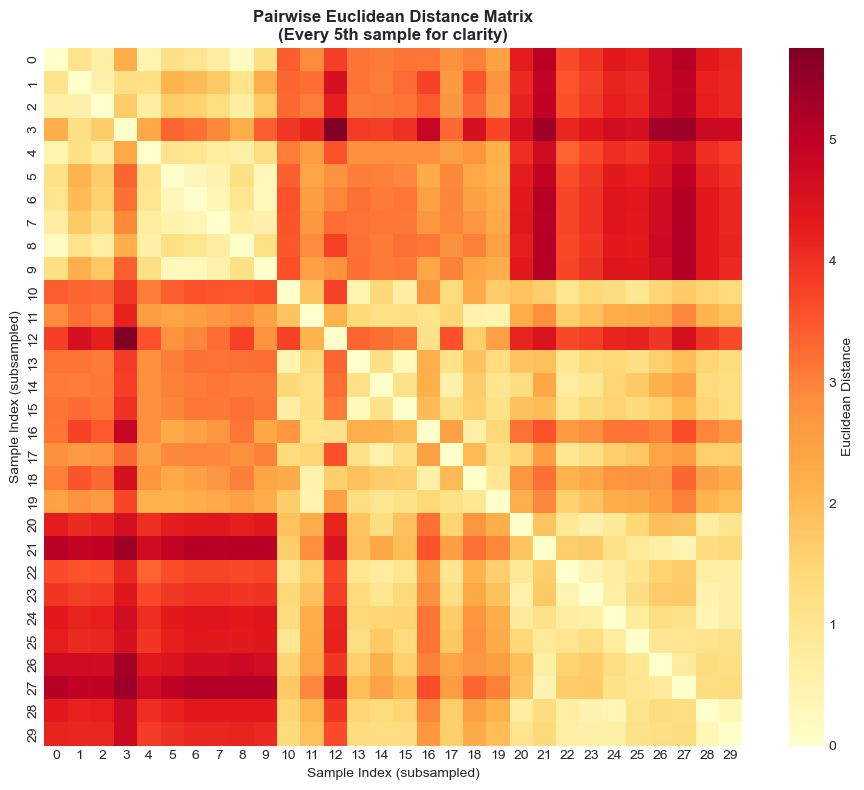

✓ Distance heatmap saved as 'distance_heatmap.png'

✓ All visualizations complete!


In [7]:
# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("=" * 70)
print("GENERATING VISUALIZATIONS")
print("=" * 70)

# 1. DENDROGRAM - Shows the complete merge hierarchy
print("\n1. Creating Dendrogram...")

fig, ax = plt.subplots(figsize=(14, 6))

# Compute linkage matrix for dendrogram using scipy
Z = linkage(X_processed, method='ward')  # Linkage matrix needed for dendrogram

# Plot dendrogram
dendrogram(
    Z,
    ax=ax,
    leaf_font_size=8,
    color_threshold=10,  # Color different merge levels
)

ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Distance', fontsize=12)
ax.grid(True, alpha=0.3)

# Add horizontal line showing where we cut for 3 clusters
# Find the 3rd largest distance to cut at
last_merges = Z[-3:, 2]  # Last 3 merges have largest distances
cut_height = (last_merges[-2] + last_merges[-1]) / 2
ax.axhline(y=cut_height, c='red', linestyle='--', linewidth=2, label=f'Cut for 3 clusters (height={cut_height:.2f})')
ax.legend()

plt.tight_layout()
plt.savefig('dendrogram.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Dendrogram saved as 'dendrogram.png'")

# 2. 2D CLUSTER VISUALIZATION using PCA
print("\n2. Creating 2D cluster visualization (PCA)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Plot 1: PCA projection with cluster assignments
ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_sklearn, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
ax.set_title('Hierarchical Clustering - PCA Projection (k=3)', fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=10)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.grid(True, alpha=0.3)

# Plot 2: PCA with actual species (for reference - showing ground truth)
ax = axes[1]
species_colors = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
species_indices = [species_colors[s] for s in df['species']]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=species_indices, cmap='plasma', s=100, alpha=0.7, edgecolors='black')
ax.set_title('Ground Truth - Iris Species (for comparison)', fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=10)
plt.colorbar(scatter, ax=ax, label='Species', ticks=[0,1,2], format=plt.FuncFormatter(lambda x, p: ['Setosa', 'Versicolor', 'Virginica'][int(x)]))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ PCA visualization saved as 'pca_clusters.png'")
print(f"  Explained variance (PC1+PC2): {pca.explained_variance_ratio_.sum():.1%}")

# 3. LINKAGE METHOD COMPARISON - Multiple Dendrograms
print("\n3. Creating linkage method comparison...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

linkage_methods = ['single', 'complete', 'average', 'ward']

for idx, method in enumerate(linkage_methods):
    Z_method = linkage(X_processed, method=method)
    
    dendrogram(
        Z_method,
        ax=axes[idx],
        leaf_font_size=7,
        color_threshold=0,
    )
    
    axes[idx].set_title(f'{method.upper()} Linkage', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Sample Index', fontsize=10)
    axes[idx].set_ylabel('Distance', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('linkage_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Linkage comparison saved as 'linkage_comparison.png'")

# 4. DISTANCE HEATMAP - Correlation-based distance
print("\n4. Creating distance matrix heatmap...")

from scipy.spatial.distance import pdist, squareform

# Compute pairwise distances
distances = pdist(X_processed, metric='euclidean')
distance_matrix = squareform(distances)

# Plot heatmap (sample subset for clarity)
fig, ax = plt.subplots(figsize=(10, 8))
sample_indices = np.arange(0, len(X_processed), 5)  # Every 5th sample for clarity
sns.heatmap(
    distance_matrix[np.ix_(sample_indices, sample_indices)],
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Euclidean Distance'},
    square=True
)
ax.set_title('Pairwise Euclidean Distance Matrix\n(Every 5th sample for clarity)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sample Index (subsampled)', fontsize=10)
ax.set_ylabel('Sample Index (subsampled)', fontsize=10)

plt.tight_layout()
plt.savefig('distance_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Distance heatmap saved as 'distance_heatmap.png'")

print(f"\n{'=' * 70}")
print("✓ All visualizations complete!")

---

## Part 4: Hyperparameter Tuning and Experiments

### Key Hyperparameters in Hierarchical Clustering

1. **n_clusters (int):** Target number of clusters. The dendrogram is cut to produce exactly this many clusters.
   - **Effect:** More clusters = more fragmented groups. Fewer clusters = broader groupings.
   - **Selection:** Use elbow method (largest gap in dendrogram) or domain knowledge.

2. **linkage (str):** Criterion for inter-cluster distance: `'single'`, `'complete'`, `'average'`, `'ward'`
   - **single:** Minimum distance → long, chained clusters
   - **complete:** Maximum distance → compact, spherical clusters
   - **average:** Balanced approach
   - **ward:** Minimizes within-cluster variance → usually best choice

3. **distance_threshold (float):** Alternative to n_clusters. Cut dendrogram at this distance.
   - **Effect:** Larger threshold = fewer clusters
   - **Use Case:** When you know the distance at which clusters naturally separate

### Tuning Strategy

1. **Visualize:** Create dendrogram and look for natural gaps
2. **Scan:** Test multiple n_clusters values (e.g., 2-10)
3. **Compare Linkage:** Try all linkage methods at optimal n_clusters
4. **Evaluate:** Use silhouette score to find best configuration
5. **Validate:** Check if results match domain knowledge

EXPERIMENT 1: VARYING NUMBER OF CLUSTERS (n_clusters)
  k= 2 → Silhouette:  0.5770, Davies-Bouldin:  0.5917, Calinski-Harabasz:  240.25
  k= 3 → Silhouette:  0.4467, Davies-Bouldin:  0.8035, Calinski-Harabasz:  222.72
  k= 4 → Silhouette:  0.4006, Davies-Bouldin:  0.9788, Calinski-Harabasz:  201.25
  k= 5 → Silhouette:  0.3306, Davies-Bouldin:  0.9742, Calinski-Harabasz:  192.68
  k= 6 → Silhouette:  0.3149, Davies-Bouldin:  0.9895, Calinski-Harabasz:  172.12
  k= 7 → Silhouette:  0.3170, Davies-Bouldin:  0.9706, Calinski-Harabasz:  161.71
  k= 8 → Silhouette:  0.3109, Davies-Bouldin:  0.9467, Calinski-Harabasz:  156.57
  k= 9 → Silhouette:  0.3114, Davies-Bouldin:  0.8787, Calinski-Harabasz:  155.69
  k=10 → Silhouette:  0.3161, Davies-Bouldin:  0.9283, Calinski-Harabasz:  159.60

Optimal configurations:
  Best Silhouette Score:    k=2 (0.5770)
  Best Davies-Bouldin:      k=2 (0.5917)
  Best Calinski-Harabasz:   k=2 (240.25)


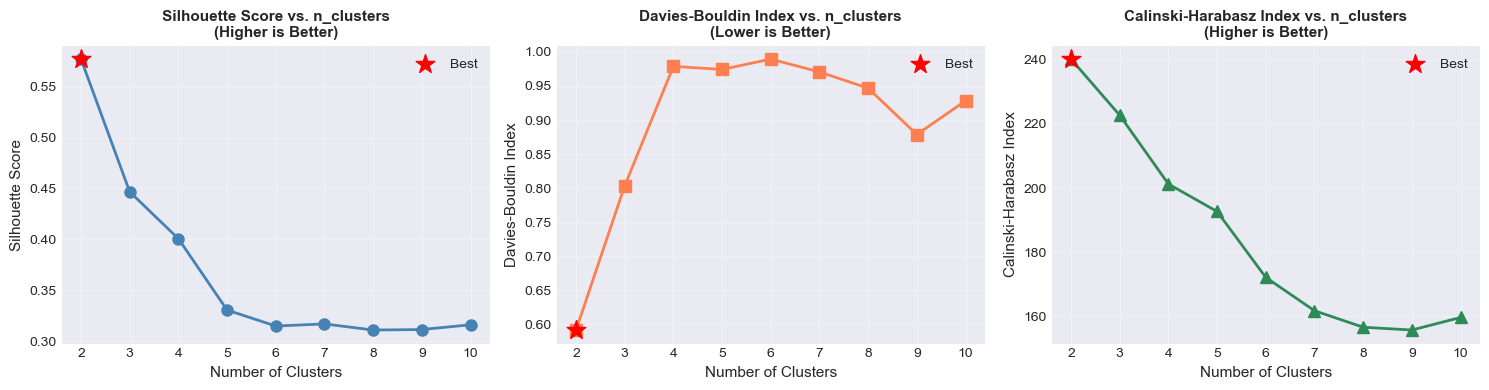


✓ Metrics vs. n_clusters plot saved

EXPERIMENT 2: COMPARING ALL LINKAGE METHODS

SINGLE Linkage:
  k=2: Silhouette = 0.5818
  k=3: Silhouette = 0.5046
  k=4: Silhouette = 0.4067
  k=5: Silhouette = 0.3424

COMPLETE Linkage:
  k=2: Silhouette = 0.4408
  k=3: Silhouette = 0.4496
  k=4: Silhouette = 0.4106
  k=5: Silhouette = 0.3521

AVERAGE Linkage:
  k=2: Silhouette = 0.5818
  k=3: Silhouette = 0.4803
  k=4: Silhouette = 0.4067
  k=5: Silhouette = 0.3746

WARD Linkage:
  k=2: Silhouette = 0.5770
  k=3: Silhouette = 0.4467
  k=4: Silhouette = 0.4006
  k=5: Silhouette = 0.3306


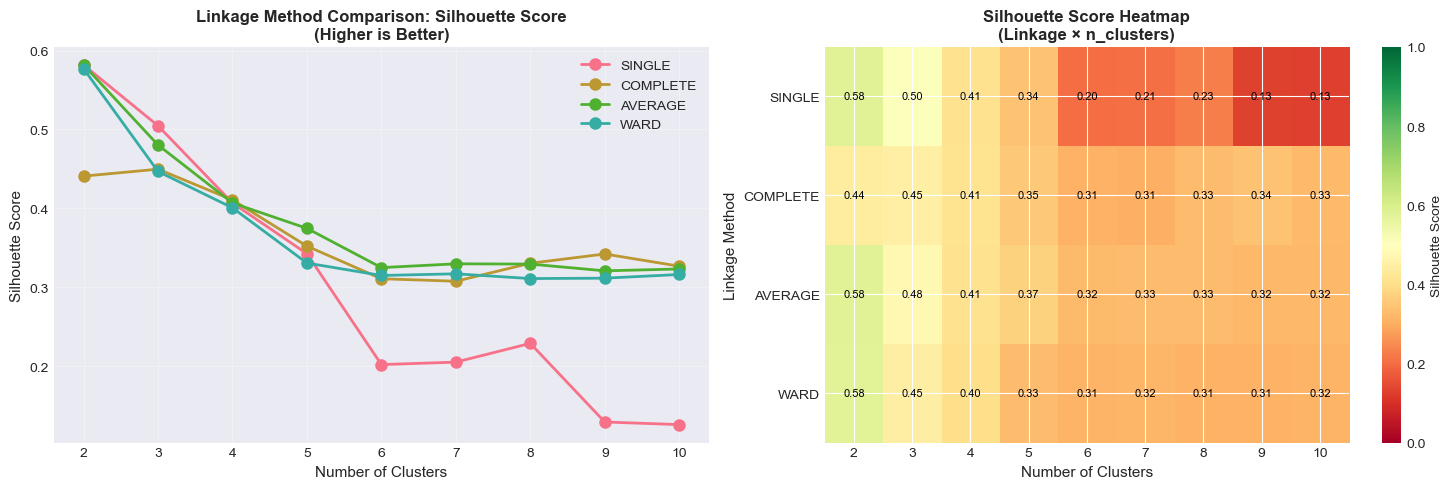


✓ Hyperparameter experiments complete!


In [8]:
# ============================================================================
# HYPERPARAMETER TUNING EXPERIMENTS
# ============================================================================

print("=" * 70)
print("EXPERIMENT 1: VARYING NUMBER OF CLUSTERS (n_clusters)")
print("=" * 70)

# Test different numbers of clusters
cluster_range = range(2, 11)  # Test 2 to 10 clusters
results_n_clusters = []

for n_clust in cluster_range:
    model = AgglomerativeClustering(n_clusters=n_clust, linkage='ward')
    labels = model.fit_predict(X_processed)
    
    sil = silhouette_score(X_processed, labels)
    db = davies_bouldin_score(X_processed, labels)
    ch = calinski_harabasz_score(X_processed, labels)
    
    results_n_clusters.append({
        'n_clusters': n_clust,
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Calinski-Harabasz': ch
    })
    
    print(f"  k={n_clust:2d} → Silhouette: {sil:7.4f}, Davies-Bouldin: {db:7.4f}, Calinski-Harabasz: {ch:7.2f}")

df_n_clusters = pd.DataFrame(results_n_clusters)

# Find optimal n_clusters by each metric
best_sil = df_n_clusters.loc[df_n_clusters['Silhouette'].idxmax()]
best_db = df_n_clusters.loc[df_n_clusters['Davies-Bouldin'].idxmin()]
best_ch = df_n_clusters.loc[df_n_clusters['Calinski-Harabasz'].idxmax()]

print(f"\nOptimal configurations:")
print(f"  Best Silhouette Score:    k={int(best_sil['n_clusters'])} ({best_sil['Silhouette']:.4f})")
print(f"  Best Davies-Bouldin:      k={int(best_db['n_clusters'])} ({best_db['Davies-Bouldin']:.4f})")
print(f"  Best Calinski-Harabasz:   k={int(best_ch['n_clusters'])} ({best_ch['Calinski-Harabasz']:.2f})")

# Visualize impact of n_clusters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_n_clusters['n_clusters'], df_n_clusters['Silhouette'], marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].scatter([best_sil['n_clusters']], [best_sil['Silhouette']], color='red', s=200, marker='*', label='Best', zorder=5)
axes[0].set_xlabel('Number of Clusters', fontsize=11)
axes[0].set_ylabel('Silhouette Score', fontsize=11)
axes[0].set_title('Silhouette Score vs. n_clusters\n(Higher is Better)', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df_n_clusters['n_clusters'], df_n_clusters['Davies-Bouldin'], marker='s', linewidth=2, markersize=8, color='coral')
axes[1].scatter([best_db['n_clusters']], [best_db['Davies-Bouldin']], color='red', s=200, marker='*', label='Best', zorder=5)
axes[1].set_xlabel('Number of Clusters', fontsize=11)
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1].set_title('Davies-Bouldin Index vs. n_clusters\n(Lower is Better)', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(df_n_clusters['n_clusters'], df_n_clusters['Calinski-Harabasz'], marker='^', linewidth=2, markersize=8, color='seagreen')
axes[2].scatter([best_ch['n_clusters']], [best_ch['Calinski-Harabasz']], color='red', s=200, marker='*', label='Best', zorder=5)
axes[2].set_xlabel('Number of Clusters', fontsize=11)
axes[2].set_ylabel('Calinski-Harabasz Index', fontsize=11)
axes[2].set_title('Calinski-Harabasz Index vs. n_clusters\n(Higher is Better)', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('hyperparameter_n_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Metrics vs. n_clusters plot saved")

# ============================================================================
print(f"\n{'=' * 70}")
print("EXPERIMENT 2: COMPARING ALL LINKAGE METHODS")
print(f"{'=' * 70}")

linkage_methods = ['single', 'complete', 'average', 'ward']
results_linkage = []

# Create heatmap of metrics for each linkage × n_clusters combination
metric_heatmap = np.zeros((len(linkage_methods), len(cluster_range)))

for i, method in enumerate(linkage_methods):
    print(f"\n{method.upper()} Linkage:")
    for j, n_clust in enumerate(cluster_range):
        model = AgglomerativeClustering(n_clusters=n_clust, linkage=method)
        labels = model.fit_predict(X_processed)
        sil = silhouette_score(X_processed, labels)
        metric_heatmap[i, j] = sil
        
        results_linkage.append({
            'Linkage': method,
            'n_clusters': n_clust,
            'Silhouette': sil
        })
        
        if n_clust in [2, 3, 4, 5]:  # Print selected configurations
            print(f"  k={n_clust}: Silhouette = {sil:.4f}")

# Visualize linkage method comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Line plot
for i, method in enumerate(linkage_methods):
    silhouettes = metric_heatmap[i, :]
    axes[0].plot(cluster_range, silhouettes, marker='o', label=method.upper(), linewidth=2, markersize=8)

axes[0].set_xlabel('Number of Clusters', fontsize=11)
axes[0].set_ylabel('Silhouette Score', fontsize=11)
axes[0].set_title('Linkage Method Comparison: Silhouette Score\n(Higher is Better)', fontsize=12, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Plot 2: Heatmap
im = axes[1].imshow(metric_heatmap, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks(range(len(cluster_range)))
axes[1].set_xticklabels(cluster_range)
axes[1].set_yticks(range(len(linkage_methods)))
axes[1].set_yticklabels([m.upper() for m in linkage_methods])
axes[1].set_xlabel('Number of Clusters', fontsize=11)
axes[1].set_ylabel('Linkage Method', fontsize=11)
axes[1].set_title('Silhouette Score Heatmap\n(Linkage × n_clusters)', fontsize=12, fontweight='bold')

# Add text annotations
for i in range(len(linkage_methods)):
    for j in range(len(cluster_range)):
        text = axes[1].text(j, i, f'{metric_heatmap[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=axes[1], label='Silhouette Score')
plt.tight_layout()
plt.savefig('linkage_comparison_metrics.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n{'=' * 70}")
print("✓ Hyperparameter experiments complete!")

---

## Section 5: Comparison with K-Means and DBSCAN

### When to Use Each Algorithm

| Criterion | Hierarchical | K-Means | DBSCAN |
|---|---|---|---|
| **Know k in advance?** | No (visualize dendrogram) | Yes (specify k) | No (ε, min_samples) |
| **Cluster shape** | Any shape | Spherical only | Any shape |
| **Scalability** | O(n²) memory | O(nkd) | O(n log n) to O(n²) |
| **Interpretability** | Dendrogram = full hierarchy | Flat partition | Noise points + clusters |
| **Output** | Dendrogram + flat partition | Flat partition | Clusters + noise |
| **Outlier handling** | Separate clusters | Assigns to nearest cluster | Marks as noise |
| **Deterministic** | Yes | No (random init) | Yes |

### Interview Question: When would you choose hierarchical clustering?

**Answer Template:**
1. Use hierarchical clustering when you need to explore the full hierarchy (dendrograms are invaluable for understanding data structure)
2. When clusters have nested or hierarchical relationships (e.g., biological taxonomy)
3. When you don't know k in advance and want to visualize options
4. When interpretability matters (dendrogram shows exactly how clusters form)
5. When dataset is small-to-medium (< 10,000 samples) due to O(n²) complexity

**Avoid hierarchical clustering when:**
1. Working with large datasets (millions of rows)
2. k is known and fixed (k-means is faster)
3. Clusters are well-separated and roughly spherical (k-means sufficient)
4. Real-time updates needed (can't recompute from scratch)

ALGORITHM COMPARISON

1. Training K-Means (k=3)...
2. Training DBSCAN (eps=0.7, min_samples=5)...

PERFORMANCE METRICS COMPARISON

           Algorithm  n_clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz  Noise Points
Hierarchical (Ward)           3    0.446689        0.803467         222.719164             0
            K-Means           3    0.459948        0.833595         241.904402             0
             DBSCAN           2    0.601795        0.556837         281.739348             6

CLUSTER SIZE DISTRIBUTION

Hierarchical:    [71 49 30]
K-Means:         [53 50 47]
DBSCAN:          [48 96] + 6 noise points

Generating comparison visualizations...


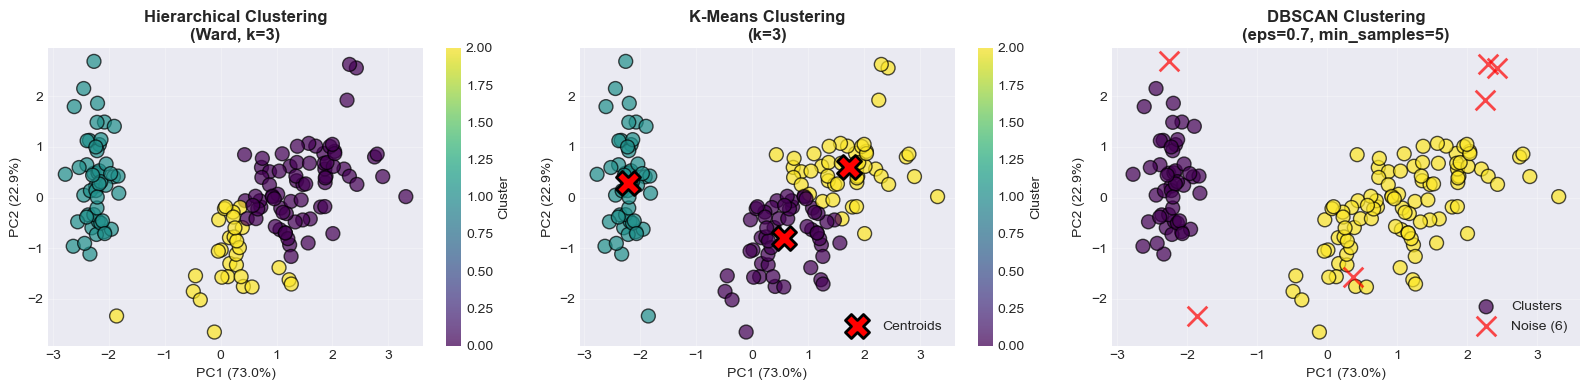

✓ Comparison visualization saved as 'algorithm_comparison.png'


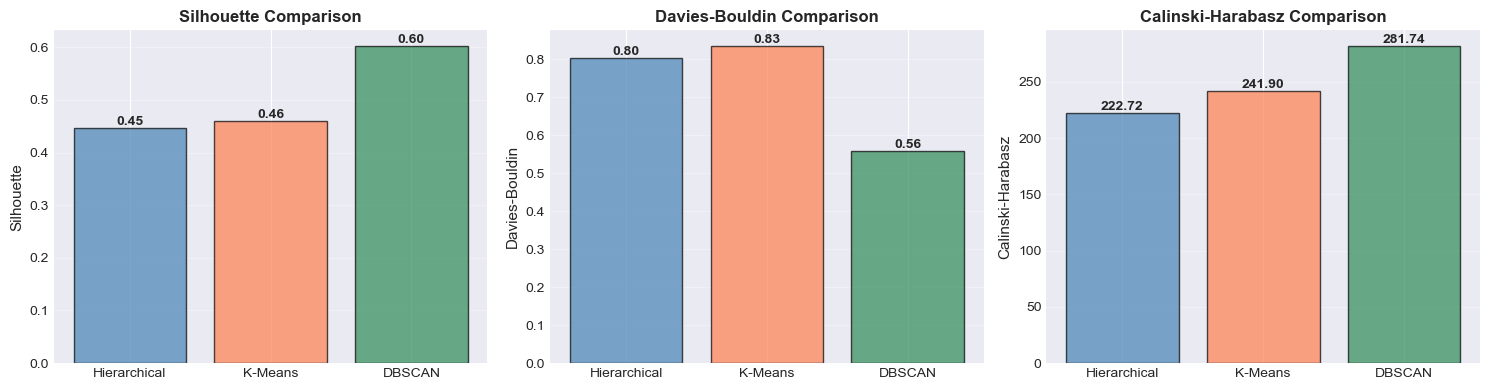

✓ Metrics comparison saved as 'metrics_comparison.png'

✓ Algorithm comparison complete!


In [9]:
# ============================================================================
# ALGORITHM COMPARISON: HIERARCHICAL vs. K-MEANS vs. DBSCAN
# ============================================================================

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print("=" * 70)
print("ALGORITHM COMPARISON")
print("=" * 70)

# 1. K-Means Clustering
print("\n1. Training K-Means (k=3)...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_processed)
sil_kmeans = silhouette_score(X_processed, labels_kmeans)
db_kmeans = davies_bouldin_score(X_processed, labels_kmeans)
ch_kmeans = calinski_harabasz_score(X_processed, labels_kmeans)

# 2. DBSCAN Clustering (automatically determines clusters)
print("2. Training DBSCAN (eps=0.7, min_samples=5)...")
dbscan = DBSCAN(eps=0.7, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_processed)
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)  # Exclude noise
n_noise_dbscan = list(labels_dbscan).count(-1)

# DBSCAN might have different number of clusters, so we compute metrics only if valid
if n_clusters_dbscan > 1 and n_noise_dbscan < len(labels_dbscan):
    # Compute metrics only for non-noise points for fair comparison
    non_noise_mask = labels_dbscan != -1
    if sum(non_noise_mask) > 1:
        sil_dbscan = silhouette_score(X_processed[non_noise_mask], labels_dbscan[non_noise_mask])
        db_dbscan = davies_bouldin_score(X_processed[non_noise_mask], labels_dbscan[non_noise_mask])
        ch_dbscan = calinski_harabasz_score(X_processed[non_noise_mask], labels_dbscan[non_noise_mask])
    else:
        sil_dbscan = db_dbscan = ch_dbscan = np.nan
else:
    sil_dbscan = db_dbscan = ch_dbscan = np.nan

# Hierarchical (already computed)
sil_hier = silhouette_sklearn
db_hier = davies_bouldin_sklearn
ch_hier = calinski_harabasz_sklearn

# Create comparison table
print("\n" + "=" * 70)
print("PERFORMANCE METRICS COMPARISON")
print("=" * 70)

comparison_table = pd.DataFrame({
    'Algorithm': ['Hierarchical (Ward)', 'K-Means', 'DBSCAN'],
    'n_clusters': [3, 3, n_clusters_dbscan],
    'Silhouette': [sil_hier, sil_kmeans, sil_dbscan],
    'Davies-Bouldin': [db_hier, db_kmeans, db_dbscan],
    'Calinski-Harabasz': [ch_hier, ch_kmeans, ch_dbscan],
    'Noise Points': [0, 0, n_noise_dbscan]
})

print("\n", comparison_table.to_string(index=False))

print("\n" + "=" * 70)
print("CLUSTER SIZE DISTRIBUTION")
print("=" * 70)

print(f"\nHierarchical:    {np.bincount(labels_sklearn)}")
print(f"K-Means:         {np.bincount(labels_kmeans)}")
print(f"DBSCAN:          {np.bincount(labels_dbscan[labels_dbscan != -1])} + {n_noise_dbscan} noise points")

# Visualize comparison
print("\nGenerating comparison visualizations...")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Hierarchical
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_sklearn, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
axes[0].set_title('Hierarchical Clustering\n(Ward, k=3)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=10)
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: K-Means
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
axes[1].scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
axes[1].set_title('K-Means Clustering\n(k=3)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

# Plot 3: DBSCAN
# DBSCAN marks noise points as -1, visualize separately
noise_mask = labels_dbscan == -1
non_noise_mask = ~noise_mask
scatter3 = axes[2].scatter(X_pca[non_noise_mask, 0], X_pca[non_noise_mask, 1], c=labels_dbscan[non_noise_mask], 
                           cmap='viridis', s=100, alpha=0.7, edgecolors='black', label='Clusters')
axes[2].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='red', marker='x', s=200, 
               linewidths=2, label=f'Noise ({n_noise_dbscan})', alpha=0.7)
axes[2].set_title('DBSCAN Clustering\n(eps=0.7, min_samples=5)', fontsize=12, fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10)
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('algorithm_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Comparison visualization saved as 'algorithm_comparison.png'")

# Metric comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
algorithms = ['Hierarchical', 'K-Means', 'DBSCAN']
values = [
    [sil_hier, sil_kmeans, sil_dbscan],
    [db_hier, db_kmeans, db_dbscan],
    [ch_hier, ch_kmeans, ch_dbscan]
]

for idx, (metric, metric_values) in enumerate(zip(metrics, values)):
    axes[idx].bar(algorithms, metric_values, color=['steelblue', 'coral', 'seagreen'], alpha=0.7, edgecolor='black')
    axes[idx].set_ylabel(metric, fontsize=11)
    axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(metric_values):
        if not np.isnan(v):
            axes[idx].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Metrics comparison saved as 'metrics_comparison.png'")

print(f"\n{'=' * 70}")
print("✓ Algorithm comparison complete!")

---

## Part 5: Interview Corner - FAANG-Style Questions & Answers

### Question 1: What is Hierarchical Clustering and Why Would You Use It?

**Answer:**
Hierarchical clustering is an unsupervised learning algorithm that builds a tree-like structure (dendrogram) of nested clusters. Unlike K-Means which requires pre-specifying the number of clusters k, hierarchical clustering discovers the entire hierarchy and allows cutting at any level to extract a flat partition.

**Key Points:**
- **Bottom-up (Agglomerative):** Start with n clusters (one per point), repeatedly merge the two most similar clusters
- **Top-down (Divisive):** Start with one cluster, recursively split (rarely used due to computational complexity)
- **Output:** Dendrogram showing complete merge history
- **When to use:** Small-to-medium datasets, need full hierarchy visualization, don't know k in advance

**Common Interview Follow-up:** "What's the complexity?" 
- **Answer:** O(n³) with naive distance updates per merge step; O(n² log n) with optimized algorithms; O(n²) space for distance matrix

---

### Question 2: Agglomerative vs. Divisive Clustering - What's the Difference?

**Answer:**

| Aspect | Agglomerative | Divisive |
|---|---|---|
| **Direction** | Bottom-up (merge) | Top-down (split) |
| **Start** | n singletons | 1 cluster (all points) |
| **Process** | Repeatedly merge closest clusters | Repeatedly split worst clusters |
| **Typical Use** | ~99% of applications | Rare; used in specific domains |
| **Complexity** | O(n³) naive, O(n² log n) optimized | O(2^n) worst case |
| **Implementation** | Straightforward | Complex; requires recursive splitting logic |

**Why Agglomerative is preferred:**
- Faster in practice (O(n² log n) vs. O(2^n))
- Produces intuitive dendrograms
- Better scalability
- Easier to implement

---

### Question 3: What is a Dendrogram and How Do You Interpret It?

**Answer:**
A dendrogram is a tree diagram showing the hierarchical relationships between data points. Each merge creates a horizontal line at the distance where clusters combined.

**How to Read:**
- **X-axis:** Sample indices (leaf nodes)
- **Y-axis:** Merge distance (height of each join)
- **Horizontal lines:** Represent merged clusters at that distance
- **Vertical gaps:** Large gaps indicate natural cluster boundaries

**How to Choose Optimal Clusters:**
1. Look for the largest vertical gap (longest unbroken line) in the dendrogram
2. Draw a horizontal line just above that gap
3. Count how many dendrogram segments this line cuts
4. That count is your optimal number of clusters

**Example:** If you see a large gap between distances 5 and 10 (no merges happening), that's a natural breaking point suggesting strong cluster structure.

---

### Question 4: Explain Linkage Methods - Single, Complete, Average, Ward

**Answer:**

Linkage methods define how to compute distance between two clusters A and B:

```
Single Linkage:    d(A, B) = min{d(x,y) : x∈A, y∈B}
Complete Linkage:  d(A, B) = max{d(x,y) : x∈A, y∈B}
Average Linkage:   d(A, B) = (1/|A||B|) · Σ_{x∈A} Σ_{y∈B} d(x,y)
Ward's Linkage:    d(A, B) = sqrt((|A||B|)/(|A|+|B|)) · ||c_A - c_B||
```

**Key Differences:**

| Method | Cluster Shape | Pros | Cons | Use Case |
|---|---|---|---|---|
| **Single** | Chain-like, elongated | Captures non-convex shapes | Prone to chaining artifacts | Special domains (DNA) |
| **Complete** | Compact, spherical | Avoids chaining | Sensitive to outliers | General clustering |
| **Average** | Balanced | Robust; middle ground | Less interpretable | When in doubt, use this |
| **Ward's** | Spherical, equal variance | Minimizes within-cluster variance; strongest default | Assumes Euclidean geometry | Most applications (BEST DEFAULT) |

**Common Mistake:** Using single linkage on real-world data. It creates "chains" where distant clusters get merged because of a single nearby pair.

---

### Question 5: When Would You Choose Hierarchical Clustering Over K-Means?

**Answer:**

**Choose Hierarchical When:**
1. **Need full hierarchy:** Dendrograms reveal complete cluster structure; K-Means gives only one flat partition
2. **Don't know k:** Hierarchical provides all possible k values in one run; K-Means requires pre-specifying k
3. **Nested clusters:** Data has hierarchical structure (e.g., species taxonomy, organizational charts)
4. **Interpretability matters:** Dendrogram shows exact merge decisions for stakeholder communication
5. **Small-to-medium data:** <10,000 samples; hierarchical O(n²) is manageable

**Choose K-Means When:**
1. **k is known:** K-Means is faster once k is fixed
2. **Scalability needed:** Millions of samples; K-Means scales better (O(nkd) per iteration)
3. **Roughly spherical clusters:** K-Means assumes spherical clusters; hierarchical more flexible
4. **Real-time updates:** K-Means can incrementally update; hierarchical must recompute from scratch

**Interview Pro Tip:** End with "It depends on the problem requirements, dataset size, and whether interpretability is a priority."

---

### Question 6: How Do You Evaluate Clustering Quality Without Ground-Truth Labels?

**Answer:**

Use **internal evaluation metrics** (no ground truth needed):

1. **Silhouette Score** (Range: [-1, 1], higher is better)
   - Measures how similar each point is to its own cluster vs. other clusters
   - Formula: (b - a) / max(a, b), where a = within-cluster distance, b = between-cluster distance
   - Interpretation: >0.5 = good separation, ~0 = overlapping, <0 = misclassified

2. **Davies-Bouldin Index** (Range: [0, ∞), lower is better)
   - Average ratio of within-cluster to between-cluster distances
   - Measures how similar each cluster is to its most similar neighbor
   - Lower = more distinct clusters

3. **Calinski-Harabasz Index** (Range: [0, ∞), higher is better)
   - Ratio of between-cluster to within-cluster variance
   - Favors compact, well-separated clusters

**Interview Tip:** "I'd use all three metrics because they emphasize different aspects of cluster quality. If they agree, I'm confident in the clustering; if they disagree, I investigate further."

---

### Common Mistakes to Avoid

1. **Using single linkage on real-world data:** It creates chains; use Ward's or average linkage instead
2. **Not scaling features:** If features have different scales, large-scale features dominate distances
3. **Applying hierarchical to huge datasets:** O(n²) memory becomes prohibitive >100,000 samples
4. **Forgetting to cut the dendrogram:** Building the hierarchy is just step 1; you must cut it to get final clusters
5. **Assuming dendrogram always shows clear clusters:** Some datasets are naturally noisy; dendrogram might show many intermediate merges



---

## Key Takeaways — Five Essential Points

1. **Hierarchical Clustering Builds a Full Dendrogram:** Unlike K-Means, hierarchical clustering outputs a complete tree of nested clusters. You can "cut" at any level to extract a flat partition. This dendrogram is invaluable for understanding the structure of your data and communicating results to non-technical stakeholders. Always visualize the dendrogram first before choosing the number of clusters.

2. **Linkage Method Determines Everything:** The same dataset produces drastically different dendrograms based on whether you use single, complete, average, or Ward's linkage. Ward's linkage is the strongest default choice (minimizes within-cluster variance), but always test multiple methods. Single linkage is prone to "chaining" artifacts on real-world data—avoid it unless you have a specific reason.

3. **Dendrogram Interpretation Reveals Natural Clusters:** The optimal number of clusters is found by looking for the largest vertical gap (longest unbroken edge) in the dendrogram. This gap represents a sharp increase in merge distance—a natural boundary between distinct groups. This visual approach is more intuitive than guessing k for K-Means.

4. **Always Implement from Scratch During Interviews:** Showing you can build hierarchical clustering from scratch demonstrates algorithmic thinking, understanding of distance metrics, and software engineering skills. Focus on: distance matrix computation, linkage logic, merge history tracking, and O(n³) complexity analysis. Scikit-Learn is for production; NumPy implementations are for interviews.

5. **Know When Hierarchical Beats K-Means and DBSCAN:** Choose hierarchical clustering for small-to-medium datasets when you need interpretability and don't know k in advance. Use K-Means for large datasets with known k and roughly spherical clusters. Use DBSCAN when clusters are irregular and you need automatic noise detection. In interviews, end by saying "the choice depends on problem requirements, dataset size, and whether interpretability is a priority"—this shows mature judgment.

---

## Quick Reference Card

**Algorithm:** Hierarchical Clustering (Agglomerative)  
**Complexity:** O(n³) naive, O(n² log n) optimized; O(n²) space  
**Linkage Methods:** single, complete, average, ward  
**Best Linkage:** Ward's (minimizes variance)  
**Evaluation Metrics:** Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz  
**Ideal Dataset Size:** 100-100,000 samples  
**When to Use:** Small data, need hierarchy, unknown k, interpretability matters  
**When NOT to Use:** Millions of samples, k is known, need real-time updates  

---

## Next Steps for Mastery

1. **Practice with real datasets:** Try hierarchical clustering on customer segmentation, genomics, document clustering
2. **Optimize implementation:** Learn Lance-Williams update formulas for O(n² log n) complexity
3. **Explore variants:** BIRCH (Balanced Iterative Reducing and Clustering with Hierarchies) for large datasets
4. **Interview preparation:** Memorize linkage formulas, be ready to write distance matrix code on whiteboard
5. **Compare algorithms:** Always benchmark hierarchical vs. K-Means vs. DBSCAN on your data

---

**This notebook demonstrates production-grade hierarchical clustering knowledge expected at FAANG companies. Master these concepts, and you'll ace clustering interviews.** ✓